In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
import numpy as np

# 1. 加载数据 (确保文件名正确)
df = pd.read_excel('updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'SLUMP', 'VOID', 'TOTAL_BINDER', 'w/b', 'b/a', 'SCM%', 'CAGG', 'FAGG', 'FA%', 'SS%', 'SF%']].values
y = df['fc (MPa)'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. 定义搜索范围 (基于你之前的随机范围)
param_grid = {
    'C': [0.1, 1, 5, 10, 20],
    'epsilon': [0.01, 0.05, 0.1, 0.2, 0.3],
    'kernel': ['linear', 'rbf']
}

# 3. 使用 GridSearchCV 寻找最佳参数
print("正在搜索最佳参数，请稍候...")
grid_search = GridSearchCV(SVR(), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_scaled, y)

# 4. 直接打印结果
best_params = grid_search.best_params_
print("\n" + "="*30)
print("   SVR 最佳参数 (用于论文中汇报)")
print("="*30)
print(f"Best Kernel:  {best_params['kernel']}")
print(f"Best C:       {best_params['C']}")
print(f"Best Epsilon: {best_params['epsilon']}")
print(f"Best R2 Score: {grid_search.best_score_:.4f}")
print("="*30)

正在搜索最佳参数，请稍候...

   SVR 最佳参数 (用于论文中汇报)
Best Kernel:  rbf
Best C:       20
Best Epsilon: 0.01
Best R2 Score: 0.4757


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import joblib
import os

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

# Define features and target
X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'SLUMP', 'VOID', 'TOTAL_BINDER', 'w/b', 'b/a', 'SCM%', 'CAGG', 'FAGG', 'FA%', 'SS%', 'SF%']].values

y = df['fc (MPa)'].values

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create a folder to save models if it doesn't exist
model_dir = "saved_svr_models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# DataFrame to store results
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE'])

# Run the model 100 times with different parameters and splits
for run in range(1, 101):
    print(f'Run {run}')
    
    # Split the data randomly each time
    Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, train_size=0.85, random_state=run)

    # Randomize SVR hyperparameters for each run
    C = np.random.uniform(0.1, 10)  # Regularization parameter
    epsilon = np.random.uniform(0.01, 0.3)  # Epsilon-tube for SVR
    kernel = np.random.choice(['linear', 'rbf'])  # Choose kernel
    
    # Create the SVR model
    svr_model = SVR(C=C, epsilon=epsilon, kernel=kernel)

    # Train the model
    svr_model.fit(Xtrain, ytrain)

    # Save the model for this run
    model_filename = os.path.join(model_dir, f'svr_model_run_{run}.joblib')
    joblib.dump(svr_model, model_filename)

    # Predict on the training and testing datasets
    ytrain_pred = svr_model.predict(Xtrain)
    ytest_pred = svr_model.predict(Xtest)

    # Evaluate the model
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)

    # Append results to DataFrame
    results_df = results_df.append({
        'Run': run,
        'Test R2': test_r2,
        'Train R2': train_r2,
        'RMSE': rmse,
        'MAE': mae
    }, ignore_index=True)

    # Print the results for this run
    print(f'Run {run}: Test R² = {test_r2}, Train R² = {train_r2}, RMSE = {rmse}, MAE = {mae}')

# Save the results to an Excel file
results_df.to_excel('svr_model_results.xlsx', index=False)

print("Results and models saved successfully.")


Run 1
Run 1: Test R² = 0.6008303950324875, Train R² = 0.6296404776920533, RMSE = 8.812414585756295, MAE = 6.482659108651005
Run 2
Run 2: Test R² = 0.4686073389433968, Train R² = 0.4893776901858208, RMSE = 10.009196783360444, MAE = 7.454996000828648
Run 3
Run 3: Test R² = 0.635552924281573, Train R² = 0.6856787405999796, RMSE = 8.38350321470129, MAE = 6.18708617459891
Run 4
Run 4: Test R² = 0.4635928210457039, Train R² = 0.4935910486319387, RMSE = 9.822978985853796, MAE = 7.293685259967453
Run 5
Run 5: Test R² = 0.5149877642566592, Train R² = 0.48616632570039686, RMSE = 9.111843549902504, MAE = 7.04188455403664
Run 6
Run 6: Test R² = 0.4689804582252739, Train R² = 0.49058030795893126, RMSE = 9.860489592287811, MAE = 7.500276203910655
Run 7
Run 7: Test R² = 0.7008301917105634, Train R² = 0.7255041308119587, RMSE = 7.98342254230032, MAE = 5.8416543575067195
Run 8
Run 8: Test R² = 0.5321453387666708, Train R² = 0.4815453484343064, RMSE = 9.488679370298293, MAE = 7.163781881904011
Run 9
Run

Run 66: Test R² = 0.6883742342669614, Train R² = 0.7386151286960507, RMSE = 7.86684507270189, MAE = 5.793872677657526
Run 67
Run 67: Test R² = 0.50625910222518, Train R² = 0.48568466617175765, RMSE = 9.60934695280198, MAE = 7.193537042600377
Run 68
Run 68: Test R² = 0.47364565270450754, Train R² = 0.49069887991274797, RMSE = 10.034994145230572, MAE = 7.48232649500377
Run 69
Run 69: Test R² = 0.4768832974988342, Train R² = 0.4878035697361748, RMSE = 9.99386385299052, MAE = 7.527402396261858
Run 70
Run 70: Test R² = 0.6819371001101033, Train R² = 0.7229153881632657, RMSE = 8.168541836154807, MAE = 6.030095738459785
Run 71
Run 71: Test R² = 0.5134375321933153, Train R² = 0.48387552093364683, RMSE = 10.193322951390023, MAE = 7.5558816711160945
Run 72
Run 72: Test R² = 0.6108107213710123, Train R² = 0.6676954352436255, RMSE = 8.648072915649353, MAE = 6.271194142919703
Run 73
Run 73: Test R² = 0.5102459429403112, Train R² = 0.4861245486916824, RMSE = 9.763766838228001, MAE = 7.33658039171251

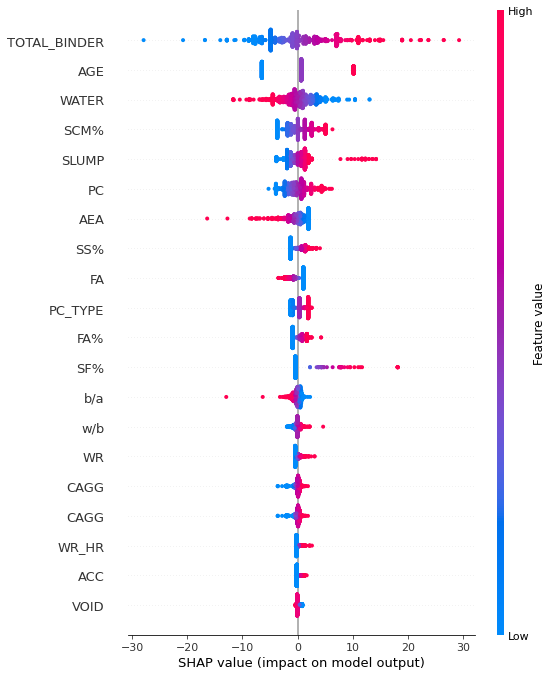

In [3]:
import shap
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the data again (as in the model training script)
df = pd.read_excel('updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

# Define features and target (same as in the original training script)
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'SLUMP', 'VOID', 'TOTAL_BINDER', 'w/b', 'b/a', 'SCM%', 'CAGG', 'FAGG', 'FA%', 'SS%', 'SF%']

X = df[features].values
y = df['fc (MPa)'].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data (we can use any run's random seed to reproduce results, here we'll use run=1)
Xtrain, Xtest, ytrain, ytest = train_test_split(X_scaled, y, train_size=0.85, random_state=1)

# Convert Xtrain and Xtest back to DataFrames with proper column names
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

# Load one of the saved models (let's pick model from run 1)
model_filename = 'saved_svr_models/svr_model_run_1.joblib'
rf_model = joblib.load(model_filename)

# Perform SHAP analysis
explainer = shap.Explainer(rf_model, Xtrain_df)  # Use the DataFrame with feature names
shap_values = explainer(Xtest_df)  # Calculate SHAP values for the test data

# Summary plot of SHAP values
shap.summary_plot(shap_values, Xtest_df)

# Force plot for the first instance in the test set, with correct feature names
shap.force_plot(
    explainer.expected_value,  # Base value for predictions
    shap_values.values[0],     # SHAP values for the first instance
    Xtest_df.iloc[0, :],       # Feature values for the first instance
    feature_names=features     # Use actual feature names
)


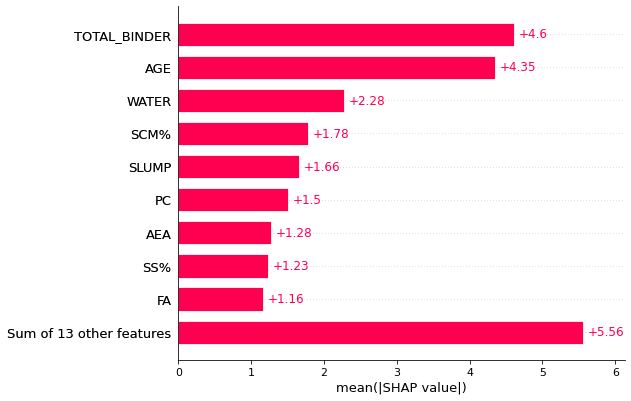

In [4]:
import shap
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the data again (as in the model training script)
df = pd.read_excel('updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

# Define features and target (same as in the original training script)
features = ['AGE', 'PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
            'SLUMP', 'VOID', 'TOTAL_BINDER', 'w/b', 'b/a', 'SCM%', 'CAGG', 'FAGG', 'FA%', 'SS%', 'SF%']

X = df[features].values
y = df['fc (MPa)'].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data (we can use any run's random seed to reproduce results, here we'll use run=1)
Xtrain, Xtest, ytrain, ytest = train_test_split(X_scaled, y, train_size=0.85, random_state=1)

# Convert Xtrain and Xtest back to DataFrames with proper column names
Xtrain_df = pd.DataFrame(Xtrain, columns=features)
Xtest_df = pd.DataFrame(Xtest, columns=features)

# Load one of the saved models (let's pick model from run 1)
model_filename = 'saved_svr_models/svr_model_run_1.joblib'
rf_model = joblib.load(model_filename)

# Perform SHAP analysis
explainer = shap.Explainer(rf_model, Xtrain_df)  # Use the DataFrame with feature names
shap_values = explainer(Xtest_df)  # Calculate SHAP values for the test data

# SHAP bar plot (global feature importance)
shap.plots.bar(shap_values)


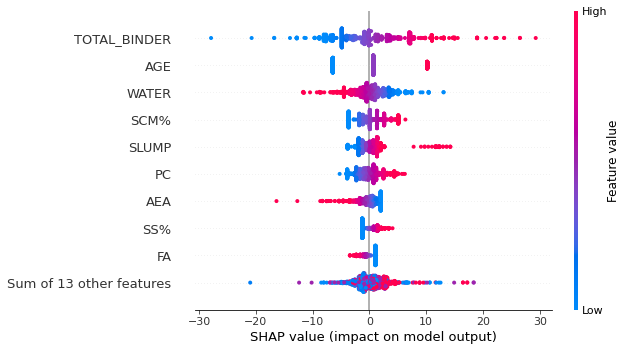

In [5]:
shap.plots.beeswarm(shap_values)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.svm import SVR
import os
import joblib

# Load and preprocess the data
df = pd.read_excel(r'updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'SS', 'SF', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'VOID', 'w/b', 'b/a', 'CAGG%', 'FAGG%', 'FA%', 'SS%', 'SF%']].values

Y = df['fc (MPa)'].values

# Normalize the data
x_mean = X.mean(0)
x_std = X.std(0)
X_normal = (X - x_mean) / x_std

y_mean = Y.mean()
y_std = Y.std()
Y_normal = (Y - y_mean) / y_std

# Hyperparameter tuning for SVR using RandomizedSearchCV
svr_model = SVR()

# Set the hyperparameters grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'epsilon': [0.01, 0.1, 0.2, 0.5, 1],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [2, 3, 4],  # Only relevant for 'poly' kernel
    'gamma': ['scale', 'auto']
}

# Randomized Search CV for hyperparameter tuning
random_search = RandomizedSearchCV(estimator=svr_model, param_distributions=param_grid, 
                                   n_iter=50, scoring='neg_mean_squared_error', 
                                   cv=3, verbose=1, random_state=42, n_jobs=-1)

random_search.fit(X_normal, Y_normal)

# Get the best hyperparameters
best_params = random_search.best_params_
print(f"Best hyperparameters: {best_params}")

# Now using the best hyperparameters for the model

# Create a folder to save models if it doesn't exist
model_dir = "SVR_best_trial"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# DataFrame to store results
results_df = pd.DataFrame(columns=['Run', 'Test R2', 'Train R2', 'RMSE', 'MAE'])

# Run the model 100 times with different parameters and splits
for run in range(1, 101):
    print(f'Run {run}')
    
    # Split the data randomly each time
    Xtrain, Xtest, ytrain, ytest = train_test_split(X_normal, Y_normal, train_size=0.85, random_state=run)

    # Create the SVR model with the best hyperparameters
    svr_model = SVR(**best_params)

    # Train the model
    svr_model.fit(Xtrain, ytrain)

    # Saving the model
    model_filename = os.path.join(model_dir, f'svr_model_run_{run}.joblib')
    joblib.dump(svr_model, model_filename)

    # Evaluate the model
    ytrain_pred = svr_model.predict(Xtrain)
    ytest_pred = svr_model.predict(Xtest)

    # Calculate metrics
    train_r2 = r2_score(ytrain, ytrain_pred)
    test_r2 = r2_score(ytest, ytest_pred)
    rmse = mean_squared_error(ytest, ytest_pred) ** 0.5
    mae = mean_absolute_error(ytest, ytest_pred)

    # Append results to DataFrame using concat
    results_df = pd.concat([results_df, pd.DataFrame([{
        'Run': run,
        'Test R2': test_r2,
        'Train R2': train_r2,
        'RMSE': rmse,
        'MAE': mae
    }])], ignore_index=True)

    # Print the results for this run
    print(f'Run {run}: Test R² = {test_r2}, Train R² = {train_r2}, RMSE = {rmse}, MAE = {mae}')

# Save the results to an Excel file
results_df.to_excel('SVR_best_trial_results.xlsx', index=False)

print("Results and models saved successfully.")


/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Fitting 3 folds for each of 50 candidates, totalling 150 fits


/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:13

Best hyperparameters: {'kernel': 'rbf', 'gamma': 'auto', 'epsilon': 0.2, 'degree': 3, 'C': 1}
Run 1
Run 1: Test R² = 0.6882762352076837, Train R² = 0.7506130346636647, RMSE = 0.5594769457603721, MAE = 0.4128228210285101
Run 2
Run 2: Test R² = 0.669041548533906, Train R² = 0.7538976157321574, RMSE = 0.5674913419448152, MAE = 0.41855725954037554
Run 3
Run 3: Test R² = 0.6808542618793504, Train R² = 0.749067627518252, RMSE = 0.5636167293073725, MAE = 0.4145927164273243
Run 4
Run 4: Test R² = 0.6896223427714896, Train R² = 0.7497722969575498, RMSE = 0.5368119807862244, MAE = 0.39169588937550814
Run 5
Run 5: Test R² = 0.6851091739503892, Train R² = 0.749986116357654, RMSE = 0.5274617379425292, MAE = 0.39755514482165677
Run 6
Run 6: Test R² = 0.6846353585023592, Train R² = 0.7490568845305139, RMSE = 0.5459222274579437, MAE = 0.40312457606619095
Run 7
Run 7: Test R² = 0.7047488924729917, Train R² = 0.7441326252923379, RMSE = 0.56977980545553, MAE = 0.41722871119428717
Run 8
Run 8: Test R² = 0

/Users/zhangtianjie/opt/anaconda3/lib/python3.8/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


Run 92: Test R² = 0.6734851152662698, Train R² = 0.7478679949038688, RMSE = 0.5891102466748054, MAE = 0.42093005140324696
Run 93
Run 93: Test R² = 0.6945863125996758, Train R² = 0.7471308198580608, RMSE = 0.5727333852242974, MAE = 0.421130405429532
Run 94
Run 94: Test R² = 0.7364315538560081, Train R² = 0.7441507636014648, RMSE = 0.5166173232080616, MAE = 0.3886009059168537
Run 95
Run 95: Test R² = 0.6606692919730609, Train R² = 0.75352237599845, RMSE = 0.5794281552892487, MAE = 0.4238205236811438
Run 96
Run 96: Test R² = 0.6914839312836494, Train R² = 0.7483546764447063, RMSE = 0.5646744739861826, MAE = 0.41199440080285726
Run 97
Run 97: Test R² = 0.6991054120796816, Train R² = 0.7488820869692765, RMSE = 0.5567592719677297, MAE = 0.40879673481940526
Run 98
Run 98: Test R² = 0.6490526188689131, Train R² = 0.7539491583331074, RMSE = 0.6052293592212535, MAE = 0.4449882873282383
Run 99
Run 99: Test R² = 0.6882184307078125, Train R² = 0.7494888468230778, RMSE = 0.5738871321020032, MAE = 0.

In [5]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import BayesianRidge
import numpy as np

# 1. 加载数据 (使用你之前的特征列表)
df = pd.read_excel('updated_fc_predictions.xlsx', sheet_name='Sheet1')
df.dropna(inplace=True)

X = df[['AGE', 'PC', 'PC_TYPE', 'FA', 'FAGG', 'CAGG', 'WATER', 'AEA', 'WR_HR', 'WR', 'ACC', 
        'SLUMP', 'VOID', 'TOTAL_BINDER', 'w/b', 'b/a', 'SCM%', 'CAGG', 'FAGG', 'FA%', 'SS%', 'SF%']].values
y = df['fc (MPa)'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. KNN 最佳参数搜索
# ==========================================
print("正在搜索 KNN 最佳参数...")
knn_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],          # 邻居数量
    'weights': ['uniform', 'distance'],       # 权重分配：统一权重或按距离加权
    'metric': ['euclidean', 'manhattan']      # 距离度量：欧式距离或曼哈顿距离
}
knn_search = GridSearchCV(KNeighborsRegressor(), knn_grid, cv=5, scoring='r2', n_jobs=-1)
knn_search.fit(X_scaled, y)

# ==========================================
# 3. BR 最佳参数搜索
# ==========================================
print("正在搜索 BR 最佳参数...")
# 贝叶斯岭回归的参数主要是 Gamma 分布的超参数，通常默认值就很稳
br_grid = {
    'n_iter': [300, 600, 1000],               # 最大迭代次数
    'tol': [1e-3, 1e-4, 1e-5],                # 收敛容差
    'alpha_1': [1e-6, 1e-5],                  # Gamma 分布参数
    'lambda_1': [1e-6, 1e-5]
}
br_search = GridSearchCV(BayesianRidge(), br_grid, cv=5, scoring='r2', n_jobs=-1)
br_search.fit(X_scaled, y)

# ==========================================
# 4. 打印结果
# ==========================================
print("\n" + "="*40)
print("       KNN 最佳参数 (用于论文汇报)")
print("="*40)
print(f"Best n_neighbors: {knn_search.best_params_['n_neighbors']}")
print(f"Best weights:     {knn_search.best_params_['weights']}")
print(f"Best metric:      {knn_search.best_params_['metric']}")
print(f"Best R2:          {knn_search.best_score_:.4f}")

print("\n" + "="*40)
print("       BR 最佳参数 (用于论文汇报)")
print("="*40)
print(f"Best n_iter:      {br_search.best_params_['n_iter']}")
print(f"Best tol:         {br_search.best_params_['tol']}")
print(f"Best R2:          {br_search.best_score_:.4f}")
print("="*40)

正在搜索 KNN 最佳参数...
正在搜索 BR 最佳参数...

       KNN 最佳参数 (用于论文汇报)
Best n_neighbors: 9
Best weights:     distance
Best metric:      euclidean
Best R2:          0.1208

       BR 最佳参数 (用于论文汇报)
Best n_iter:      300
Best tol:         0.001
Best R2:          0.0950
